In [1]:
from google.colab import files

uploaded = files.upload()

Saving Nassau Candy Distributor.csv to Nassau Candy Distributor.csv


In [3]:
import pandas as pd


In [4]:
df = pd.read_csv("Nassau Candy Distributor.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'],dayfirst= True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],dayfirst = True)


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  int64         
 6   Country/Region  10194 non-null  object        
 7   City            10194 non-null  object        
 8   State/Province  10194 non-null  object        
 9   Postal Code     10194 non-null  object        
 10  Division        10194 non-null  object        
 11  Region          10194 non-null  object        
 12  Product ID      10194 non-null  object        
 13  Product Name    10194 non-null  object        
 14  Sales           10194 non-null  float64       
 15  Un

In [15]:
df['Lead_time'] =  (df['Ship Date'] - df['Order Date']).dt.days

In [16]:
df['Lead_time'].head()

,Lead_time
0,909
1,909
2,909
3,909
4,912


In [17]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost', 'Lead_time'],
      dtype='object')

In [18]:
factory_mapping = {

    "Wonka Bar - Nutty Crunch Surprise":"Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows":"Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious":"Lot's O' Nuts",

    "Wonka Bar - Milk Chocolate":"Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel":"Wicked Choccy's",

    "Laffy Taffy":"Sugar Shack",
    "SweeTARTS":"Sugar Shack",
    "Nerds":"Sugar Shack",
    "Fun Dip":"Sugar Shack",
    "Fizzy Lifting Drinks":"Sugar Shack",

    "Everlasting Gobstopper":"Secret Factory",

    "Hair Toffee":"The Other Factory",

    "Lickable Wallpaper":"Secret Factory",
    "Wonka Gum":"Secret Factory",

    "Kazookles":"The Other Factory"
}

In [19]:
df["Factory"] = df["Product Name"].map(factory_mapping)

In [20]:
factory_mapping["Nerds"]

'Sugar Shack'

In [21]:
df[
    ["Product Name","Factory"]
].head(20)

,Product Name,Factory
0,Wonka Bar - Milk Chocolate,Wicked Choccy's
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
5,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
6,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
7,Wonka Bar - Milk Chocolate,Wicked Choccy's
8,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
9,Wonka Bar - Milk Chocolate,Wicked Choccy's


In [22]:
df["Factory"] = df["Product Name"].map(factory_mapping)


In [23]:
df[["Product Name","Factory"]].head(20)

,Product Name,Factory
0,Wonka Bar - Milk Chocolate,Wicked Choccy's
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
5,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
6,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
7,Wonka Bar - Milk Chocolate,Wicked Choccy's
8,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
9,Wonka Bar - Milk Chocolate,Wicked Choccy's


In [24]:
df["Factory"].isnull().sum()

np.int64(0)

In [25]:
# Which factory generates the highest sales?

factory_sales = (
    df.groupby("Factory")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

factory_sales

,Sales
Factory,
Lot's O' Nuts,76340.15
Wicked Choccy's,55352.75
Secret Factory,8587.50
The Other Factory,1282.25
Sugar Shack,220.98


In [31]:
# Which factory generates the highest profit?
factory_profit = (
    df.groupby("Factory")["Gross Profit"]
    .sum()
    .sort_values(ascending= False)
)

factory_profit

,Gross Profit
Factory,
Lot's O' Nuts,52771.05
Wicked Choccy's,36053.57
Secret Factory,4344.70
The Other Factory,152.25
Sugar Shack,121.23


In [33]:
# Which factory sells the most units?
factory_units =(
    df.groupby("Factory")["Units"]
    .sum()
    .sort_values(ascending= False)
)

factory_units

,Units
Factory,
Lot's O' Nuts,21412
Wicked Choccy's,15863
Secret Factory,884
The Other Factory,388
Sugar Shack,107


In [39]:
# Average Lead Time by Factory
factory_leadtime = (
    df.groupby("Factory")["Lead_time"]
    .mean()
    .sort_values(ascending=False)
)


factory_leadtime


,Lead_time
Factory,
Sugar Shack,1340.030303
Secret Factory,1321.870968
Lot's O' Nuts,1321.228742
Wicked Choccy's,1321.082129
The Other Factory,1280.280000


In [40]:
import matplotlib.pyplot as plt


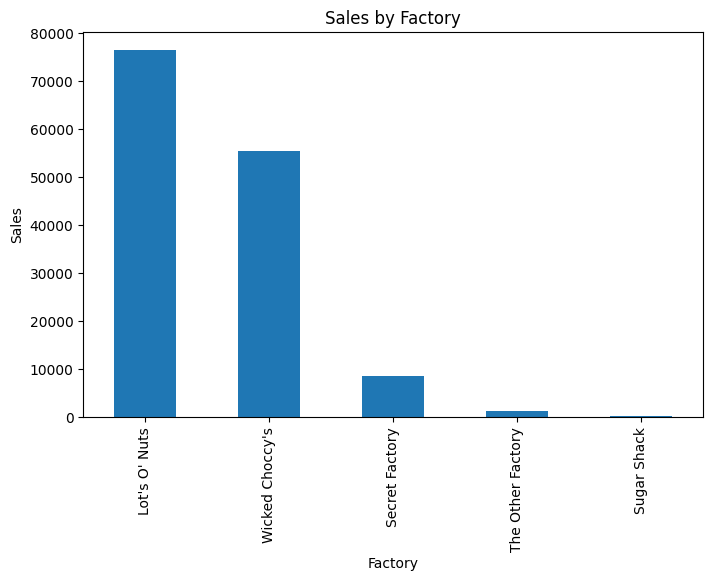

In [42]:
# Sales by Factory
factory_sales.plot(
    kind= "bar",
    figsize= (8,5)
)
plt.title("Sales by Factory")
plt.ylabel("Sales")
plt.show()


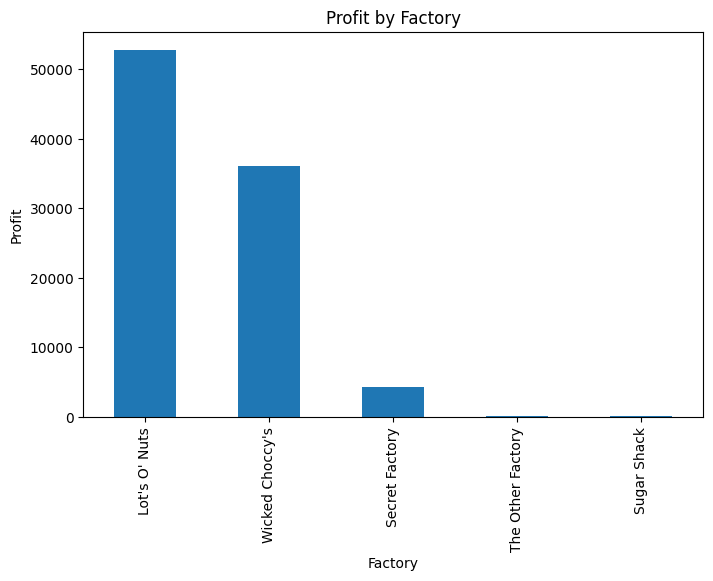

In [43]:
# Profit by Factory
factory_profit.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Profit by Factory")
plt.ylabel("Profit")
plt.show()

In [45]:
# Factory Summary Table

factory_summary = (
    df.groupby("Factory")
    .agg({
        "Sales":"sum",
        "Gross Profit":"sum",
        "Units":"sum",
        "Lead_time":"mean"
    })
    .round(2)
)

factory_summary

,Sales,Gross Profit,Units,Lead_time
Factory,,,,
Lot's O' Nuts,76340.15,52771.05,21412,1321.23
Secret Factory,8587.50,4344.70,884,1321.87
Sugar Shack,220.98,121.23,107,1340.03
The Other Factory,1282.25,152.25,388,1280.28
Wicked Choccy's,55352.75,36053.57,15863,1321.08


In [46]:
# Sales Rank
factory_summary["Sales_Rank"] = (
    factory_summary["Sales"]
    .rank(ascending=False)
)

In [47]:
# Profit Rank
factory_summary["Profit_Rank"] = (
    factory_summary["Gross Profit"]
    .rank(ascending=False)
)

In [49]:
# Lead Time Rank
factory_summary["LeadTime_Rank"] = (
    factory_summary["Lead_time"]
    .rank(ascending=True)
)

In [50]:
# Efficiency Score
factory_summary["Efficiency_Score"] = (
    factory_summary["Sales_Rank"]
    +
    factory_summary["Profit_Rank"]
    +
    factory_summary["LeadTime_Rank"]
)


In [51]:
# Sort
factory_summary.sort_values(
    "Efficiency_Score"
)

,Sales,Gross Profit,Units,Lead_time,Sales_Rank,Profit_Rank,LeadTime_Rank,Efficiency_Score
Factory,,,,,,,,
Lot's O' Nuts,76340.15,52771.05,21412,1321.23,1.0,1.0,3.0,5.0
Wicked Choccy's,55352.75,36053.57,15863,1321.08,2.0,2.0,2.0,6.0
The Other Factory,1282.25,152.25,388,1280.28,4.0,4.0,1.0,9.0
Secret Factory,8587.50,4344.70,884,1321.87,3.0,3.0,4.0,10.0
Sugar Shack,220.98,121.23,107,1340.03,5.0,5.0,5.0,15.0


In [53]:
# Product Performance by Factory

product_summary = (
    df.groupby(
        ["Factory","Product Name"]
    )
    .agg({
        "Sales":"sum",
        "Gross Profit":"sum",
        "Units":"sum",
        "Lead_time":"mean"
    })
    .round(2)
    .reset_index()
)

product_summary

,Factory,Product Name,Sales,Gross Profit,Units,Lead_time
0,Lot's O' Nuts,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,1314.24
1,Lot's O' Nuts,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,1328.92
2,Lot's O' Nuts,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,1320.64
3,Secret Factory,Everlasting Gobstopper,130.00,104.00,13,1394.67
4,Secret Factory,Lickable Wallpaper,7860.00,3930.00,393,1339.14
5,Secret Factory,Wonka Gum,597.50,310.70,478,1306.53
6,Sugar Shack,Fizzy Lifting Drinks,78.75,47.25,21,1273.50
7,Sugar Shack,Fun Dip,12.00,4.80,8,1272.67
8,Sugar Shack,Laffy Taffy,53.73,33.48,27,1383.10
9,Sugar Shack,Nerds,15.00,7.00,10,1274.00


In [54]:
# Sort by Sales
product_summary.sort_values(
    by="Sales",
    ascending=False
).head(20)

,Factory,Product Name,Sales,Gross Profit,Units,Lead_time
14,Wicked Choccy's,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,1325.66
2,Lot's O' Nuts,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,1320.64
13,Wicked Choccy's,Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,1316.76
0,Lot's O' Nuts,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,1314.24
1,Lot's O' Nuts,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,1328.92
4,Secret Factory,Lickable Wallpaper,7860.00,3930.00,393,1339.14
12,The Other Factory,Kazookles,1205.75,92.75,371,1272.99
5,Secret Factory,Wonka Gum,597.50,310.70,478,1306.53
3,Secret Factory,Everlasting Gobstopper,130.00,104.00,13,1394.67
6,Sugar Shack,Fizzy Lifting Drinks,78.75,47.25,21,1273.50


In [55]:
# Top Products
top_products = (
    product_summary
    .sort_values(
        by="Sales",
        ascending=False
    )
)

top_products.head(15)

,Factory,Product Name,Sales,Gross Profit,Units,Lead_time
14,Wicked Choccy's,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,1325.66
2,Lot's O' Nuts,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,1320.64
13,Wicked Choccy's,Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,1316.76
0,Lot's O' Nuts,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,1314.24
1,Lot's O' Nuts,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,1328.92
4,Secret Factory,Lickable Wallpaper,7860.00,3930.00,393,1339.14
12,The Other Factory,Kazookles,1205.75,92.75,371,1272.99
5,Secret Factory,Wonka Gum,597.50,310.70,478,1306.53
3,Secret Factory,Everlasting Gobstopper,130.00,104.00,13,1394.67
6,Sugar Shack,Fizzy Lifting Drinks,78.75,47.25,21,1273.50


In [56]:
product_summary

,Factory,Product Name,Sales,Gross Profit,Units,Lead_time
0,Lot's O' Nuts,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,1314.24
1,Lot's O' Nuts,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,1328.92
2,Lot's O' Nuts,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,1320.64
3,Secret Factory,Everlasting Gobstopper,130.00,104.00,13,1394.67
4,Secret Factory,Lickable Wallpaper,7860.00,3930.00,393,1339.14
5,Secret Factory,Wonka Gum,597.50,310.70,478,1306.53
6,Sugar Shack,Fizzy Lifting Drinks,78.75,47.25,21,1273.50
7,Sugar Shack,Fun Dip,12.00,4.80,8,1272.67
8,Sugar Shack,Laffy Taffy,53.73,33.48,27,1383.10
9,Sugar Shack,Nerds,15.00,7.00,10,1274.00


In [57]:
top_products.head(15)

,Factory,Product Name,Sales,Gross Profit,Units,Lead_time
14,Wicked Choccy's,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,1325.66
2,Lot's O' Nuts,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,1320.64
13,Wicked Choccy's,Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,1316.76
0,Lot's O' Nuts,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,1314.24
1,Lot's O' Nuts,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,1328.92
4,Secret Factory,Lickable Wallpaper,7860.00,3930.00,393,1339.14
12,The Other Factory,Kazookles,1205.75,92.75,371,1272.99
5,Secret Factory,Wonka Gum,597.50,310.70,478,1306.53
3,Secret Factory,Everlasting Gobstopper,130.00,104.00,13,1394.67
6,Sugar Shack,Fizzy Lifting Drinks,78.75,47.25,21,1273.50


In [58]:
# Product Priority Score
product_summary["Sales_Rank"] = (
    product_summary["Sales"]
    .rank(ascending=False)
)

product_summary["Profit_Rank"] = (
    product_summary["Gross Profit"]
    .rank(ascending=False)
)

product_summary["LeadTime_Rank"] = (
    product_summary["Lead_time"]
    .rank(ascending=True)
)

product_summary["Priority_Score"] = (
    product_summary["Sales_Rank"]
    +
    product_summary["Profit_Rank"]
    +
    product_summary["LeadTime_Rank"]
)

product_summary.sort_values(
    "Priority_Score"
)

,Factory,Product Name,Sales,Gross Profit,Units,Lead_time,Sales_Rank,Profit_Rank,LeadTime_Rank,Priority_Score
2,Lot's O' Nuts,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,1320.64,2.0,1.0,8.0,11.0
14,Wicked Choccy's,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,1325.66,1.0,2.0,9.0,12.0
13,Wicked Choccy's,Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,1316.76,3.0,3.0,7.0,13.0
0,Lot's O' Nuts,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,1314.24,4.0,5.0,6.0,15.0
12,The Other Factory,Kazookles,1205.75,92.75,371,1272.99,7.0,9.0,2.0,18.0
1,Lot's O' Nuts,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,1328.92,5.0,4.0,10.0,19.0
5,Secret Factory,Wonka Gum,597.50,310.70,478,1306.53,8.0,7.0,5.0,20.0
4,Secret Factory,Lickable Wallpaper,7860.00,3930.00,393,1339.14,6.0,6.0,11.0,23.0
6,Sugar Shack,Fizzy Lifting Drinks,78.75,47.25,21,1273.50,10.0,11.0,3.0,24.0
3,Secret Factory,Everlasting Gobstopper,130.00,104.00,13,1394.67,9.0,8.0,14.0,31.0


In [60]:
# Recommendation Dataset
import numpy as np


recommendation_df = product_summary.copy()

recommendation_df["Recommendation"] = np.where(
    recommendation_df["Priority_Score"] <= 15,
    "Retain Current Factory",
    np.where(
        recommendation_df["Priority_Score"] <= 30,
        "Monitor Performance",
        "Review Factory Allocation"
    )
)

recommendation_df[
    [
        "Factory",
        "Product Name",
        "Sales",
        "Gross Profit",
        "Lead_time",
        "Priority_Score",
        "Recommendation"
    ]
].sort_values(
    by="Priority_Score"
)

,Factory,Product Name,Sales,Gross Profit,Lead_time,Priority_Score,Recommendation
2,Lot's O' Nuts,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,1320.64,11.0,Retain Current Factory
14,Wicked Choccy's,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,1325.66,12.0,Retain Current Factory
13,Wicked Choccy's,Wonka Bar - Milk Chocolate,26867.75,17443.37,1316.76,13.0,Retain Current Factory
0,Lot's O' Nuts,Wonka Bar - Fudge Mallows,24890.40,16593.60,1314.24,15.0,Retain Current Factory
12,The Other Factory,Kazookles,1205.75,92.75,1272.99,18.0,Monitor Performance
1,Lot's O' Nuts,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,1328.92,19.0,Monitor Performance
5,Secret Factory,Wonka Gum,597.50,310.70,1306.53,20.0,Monitor Performance
4,Secret Factory,Lickable Wallpaper,7860.00,3930.00,1339.14,23.0,Monitor Performance
6,Sugar Shack,Fizzy Lifting Drinks,78.75,47.25,1273.50,24.0,Monitor Performance
3,Secret Factory,Everlasting Gobstopper,130.00,104.00,1394.67,31.0,Review Factory Allocation


In [61]:
recommendation_df.to_csv(
    "Factory_Recommendations.csv",
    index=False
)

In [62]:
factory_summary.to_csv(
    "Factory_Summary.csv",
    index=False
)

In [63]:
product_summary.to_csv(
    "Product_Summary.csv",
    index=False
)

In [65]:
kpi = pd.DataFrame({
    "Metric":[
        "Total Sales",
        "Total Profit",
        "Total Units",
        "Average Lead Time"
    ],
    "Value":[
        df["Sales"].sum(),
        df["Gross Profit"].sum(),
        df["Units"].sum(),
        round(df["Lead_time"].mean(),2)
    ]
})

kpi

,Metric,Value
0,Total Sales,141783.63
1,Total Profit,93442.80
2,Total Units,38654.00
3,Average Lead Time,1320.84


In [66]:
kpi.to_csv(
    "KPI_Table.csv",
    index=False
)